# 03 - Anomaly Detector Test
Owner: Shreya

Checks:
- detector correctly flags agents with abnormal HO trigger rates
- detector correctly flags agents deviating from consensus
- honest agents are NOT falsely flagged
- trust deltas are negative for flagged, positive for honest

NOTE: this is a unit-level test — no real env needed, we feed synthetic data

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.abspath('..'))
from security.anomaly_detector import AnomalyDetector

# 7 agents, cell_0 and cell_3 will be Byzantine
agent_ids = [f'cell_{i}' for i in range(7)]
BYZANTINE = ['cell_0', 'cell_3']
HONEST = [a for a in agent_ids if a not in BYZANTINE]

detector = AnomalyDetector(agent_ids)
print('Detector initialized for:', agent_ids)

Detector initialized for: ['cell_0', 'cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6']


In [7]:
# feed synthetic data
# honest agents: mixed actions, mostly agree with consensus
# Byzantine agents: always TRIGGER_HO (action=2), rarely agree with consensus

np.random.seed(42)
NUM_STEPS = 50

for step in range(NUM_STEPS):
    actions = {}
    consensus_decisions = {}
    rewards = {}

    for agent in agent_ids:
        if agent in BYZANTINE:
            # Byzantine: always trigger HO regardless of state
            actions[agent] = 2
            consensus_decisions[agent] = np.random.choice([0, 1])  # consensus says stay/prepare
            rewards[agent] = np.random.uniform(-1.0, 0.0) # bad rewards
        else:
            # honest: varied actions, mostly follow consensus
            action = np.random.choice([0, 1, 2], p=[0.5, 0.3, 0.2])
            actions[agent] = action
            # honest agents agree with consensus ~80% of time
            consensus_decisions[agent] = action if np.random.rand() < 0.8 \
                                         else np.random.choice([0, 1, 2])
            rewards[agent] = np.random.uniform(0.0, 1.0)

    detector.record_step(actions, consensus_decisions, rewards)

print(f'Fed {NUM_STEPS} steps of synthetic data')

Fed 50 steps of synthetic data


In [8]:
# run detection
flagged, trust_deltas = detector.detect(step=NUM_STEPS)

print('Flagged agents:', flagged)
print('Trust deltas:', trust_deltas)

# - assertions
for b in BYZANTINE:
    assert b in flagged, f'FAIL: Byzantine agent {b} not flagged'
    assert trust_deltas[b] < 0, f'FAIL: Byzantine agent {b} trust delta should be negative'

for h in HONEST:
    assert h not in flagged, f'FAIL: honest agent {h} falsely flagged'
    assert trust_deltas[h] >= 0, f'FAIL: honest agent {h} trust delta should be non-negative'

print('All assertions passed')

Flagged agents: ['cell_0', 'cell_3']
Trust deltas: {'cell_0': -0.5, 'cell_1': 0.05, 'cell_2': 0.05, 'cell_3': -0.5, 'cell_4': 0.05, 'cell_5': 0.05, 'cell_6': 0.05}
All assertions passed


In [9]:
# agent summaries
summaries = [detector.get_agent_summary(a) for a in agent_ids]
for s in summaries:
    tag = 'BYZANTINE' if s['agent_id'] in BYZANTINE else 'honest'
    print(
        f"[{tag:>9}] {s['agent_id']} | "
        f"HO rate: {s['ho_trigger_rate']:.2f} | "
        f"consensus agreement: {s['consensus_agreement']:.2f} | "
        f"avg reward: {s['avg_reward']:.3f}"
    )

[BYZANTINE] cell_0 | HO rate: 1.00 | consensus agreement: 0.00 | avg reward: -0.510
[   honest] cell_1 | HO rate: 0.30 | consensus agreement: 0.85 | avg reward: 0.466
[   honest] cell_2 | HO rate: 0.15 | consensus agreement: 0.95 | avg reward: 0.444
[BYZANTINE] cell_3 | HO rate: 1.00 | consensus agreement: 0.00 | avg reward: -0.477
[   honest] cell_4 | HO rate: 0.10 | consensus agreement: 0.95 | avg reward: 0.587
[   honest] cell_5 | HO rate: 0.15 | consensus agreement: 0.75 | avg reward: 0.432
[   honest] cell_6 | HO rate: 0.20 | consensus agreement: 0.95 | avg reward: 0.467


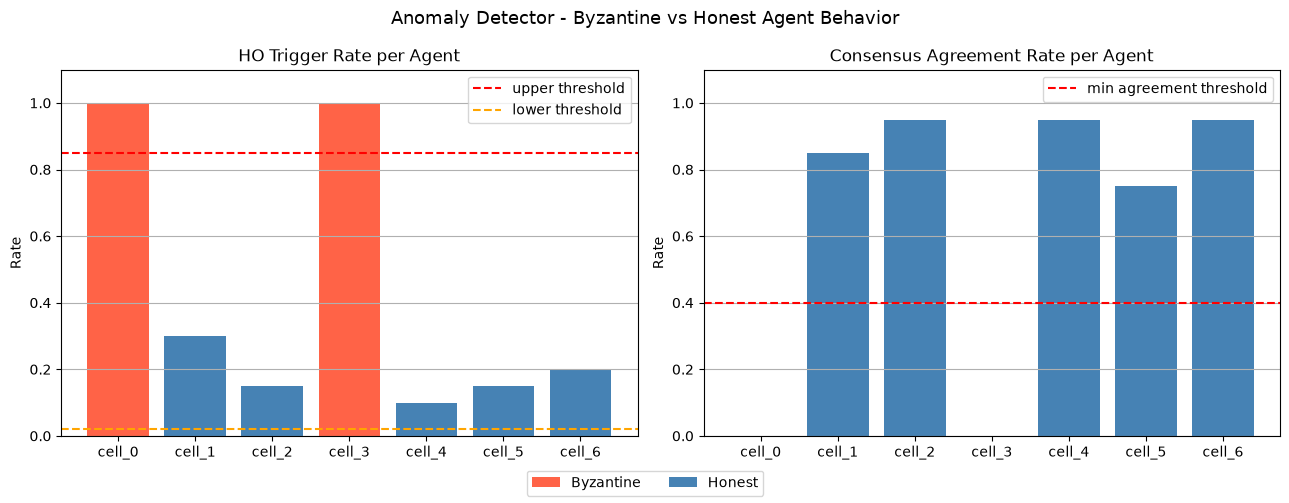

In [10]:
# pPlot: HO trigger rate + consensus agreement per agent
ho_rates = [detector.histories[a].ho_trigger_rate for a in agent_ids]
agreement_rates = [detector.histories[a].consensus_agreement_rate for a in agent_ids]
colors = ['tomato' if a in BYZANTINE else 'steelblue' for a in agent_ids]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(agent_ids, ho_rates, color=colors)
axes[0].axhline(0.85, color='red', linestyle='--', label='upper threshold')
axes[0].axhline(0.02, color='orange', linestyle='--', label='lower threshold')
axes[0].set_title('HO Trigger Rate per Agent')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(axis='y')

bars2 = axes[1].bar(agent_ids, agreement_rates, color=colors)
axes[1].axhline(0.4, color='red', linestyle='--', label='min agreement threshold')
axes[1].set_title('Consensus Agreement Rate per Agent')
axes[1].set_ylabel('Rate')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(axis='y')

# legend: red = Byzantine, blue = honest
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='Byzantine'),
                   Patch(facecolor='steelblue', label='Honest')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)

plt.suptitle('Anomaly Detector - Byzantine vs Honest Agent Behavior', fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('../results/plots/anomaly_detector_test.png', dpi=150)
plt.show()

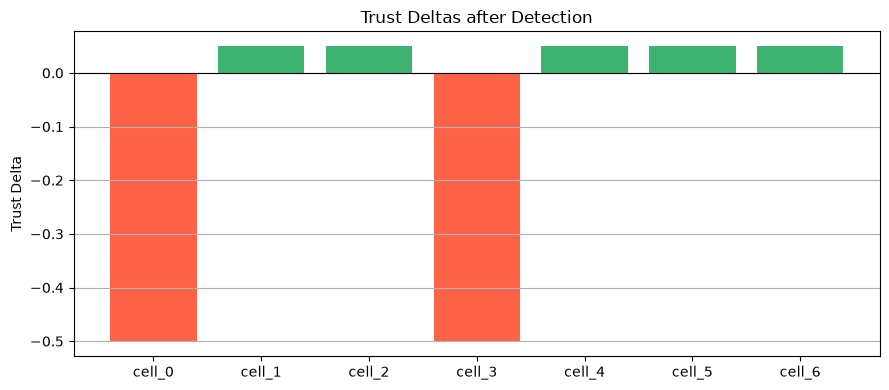

In [11]:
# trust deltas bar chart
deltas = [trust_deltas[a] for a in agent_ids]
delta_colors = ['tomato' if d < 0 else 'mediumseagreen' for d in deltas]

plt.figure(figsize=(9, 4))
plt.bar(agent_ids, deltas, color=delta_colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Trust Deltas after Detection')
plt.ylabel('Trust Delta')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('../results/plots/trust_deltas.png', dpi=150)
plt.show()

# Shravani: these deltas feed into trust.py update_trust_score()